In [2]:
import pandas as pd
import numpy as np

In [4]:
nav = pd.read_csv("../data/cleaned_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [8]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [10]:
var_cvar = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(returns, 5)

        cvar_95 = returns[returns <= var_95].mean()

        var_cvar.append([
            code,
            var_95,
            cvar_95
        ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [12]:
var_cvar_df.to_csv(
    "../data/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv created successfully!")

var_cvar_report.csv created successfully!


In [14]:
var_cvar_df.shape

(40, 3)

In [16]:
import os

os.path.exists("../data/var_cvar_report.csv")

True

In [18]:
perf = pd.read_csv("../data/07_scheme_performance.csv")

perf.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [20]:
scorecard = pd.read_csv("../data/fund_scorecard.csv")

scorecard[['amfi_code','scheme_name','sharpe_ratio']]\
.sort_values('sharpe_ratio', ascending=False)\
.head(5)

KeyError: "['scheme_name'] not in index"

In [22]:
scorecard.columns

Index(['amfi_code', 'cagr_pct', 'sharpe_ratio', 'sortino_ratio',
       'max_drawdown_pct', 'alpha', 'beta'],
      dtype='object')

In [24]:
perf[['amfi_code','scheme_name','sharpe_ratio']] \
.sort_values('sharpe_ratio', ascending=False) \
.head(5)

,amfi_code,scheme_name,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


In [26]:
top5_codes = [120507, 120844, 101208, 100025, 119120]

top_nav = nav[
    nav['amfi_code'].isin(top5_codes)
].copy()

top_nav.shape

(5750, 4)

In [28]:
top_nav = top_nav.sort_values(
    ['amfi_code', 'date']
)

top_nav['rolling_sharpe'] = (
    top_nav.groupby('amfi_code')['daily_return']
    .transform(
        lambda x:
        (x.rolling(90).mean() /
         x.rolling(90).std()) * np.sqrt(252)
    )
)

top_nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
1150,100025,2022-01-03,26.3169,NaN,NaN
1151,100025,2022-01-04,26.2234,-0.003553,NaN
1152,100025,2022-01-05,26.2221,-0.000050,NaN
1153,100025,2022-01-06,26.1728,-0.001880,NaN
1154,100025,2022-01-07,26.2261,0.002036,NaN


In [30]:
top_nav = top_nav.sort_values(
    ['amfi_code', 'date']
)

top_nav['rolling_sharpe'] = (
    top_nav.groupby('amfi_code')['daily_return']
    .transform(
        lambda x:
        (x.rolling(90).mean() /
         x.rolling(90).std()) * np.sqrt(252)
    )
)

top_nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
1150,100025,2022-01-03,26.3169,NaN,NaN
1151,100025,2022-01-04,26.2234,-0.003553,NaN
1152,100025,2022-01-05,26.2221,-0.000050,NaN
1153,100025,2022-01-06,26.1728,-0.001880,NaN
1154,100025,2022-01-07,26.2261,0.002036,NaN


In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top_nav['scheme_name'].unique():

    fund_data = top_nav[
        top_nav['scheme_name'] == fund
    ]

    plt.plot(
        fund_data['date'],
        fund_data['rolling_sharpe'],
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../data/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

KeyError: 'scheme_name'

<Figure size 1200x600 with 0 Axes>

In [34]:
top_nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return', 'rolling_sharpe'], dtype='object')

In [36]:
name_map = perf.set_index('amfi_code')['scheme_name'].to_dict()

top_nav['scheme_name'] = top_nav['amfi_code'].map(name_map)

In [38]:
top_nav[['amfi_code','scheme_name']].head()

,amfi_code,scheme_name
1150,100025,HDFC Short Term Debt Fund - Regular - Growth
1151,100025,HDFC Short Term Debt Fund - Regular - Growth
1152,100025,HDFC Short Term Debt Fund - Regular - Growth
1153,100025,HDFC Short Term Debt Fund - Regular - Growth
1154,100025,HDFC Short Term Debt Fund - Regular - Growth


In [40]:
top_nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return', 'rolling_sharpe',
       'scheme_name'],
      dtype='object')

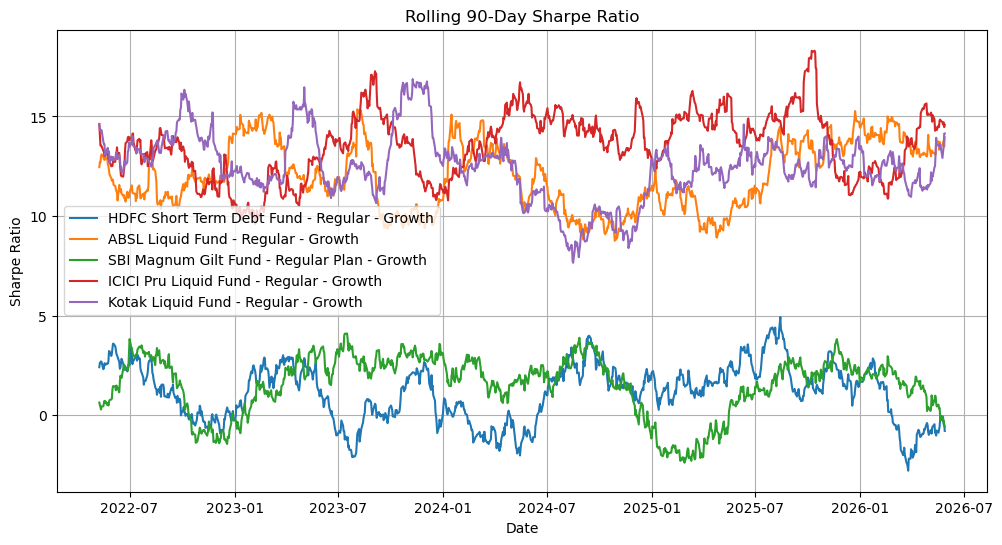

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top_nav['scheme_name'].unique():

    fund_data = top_nav[
        top_nav['scheme_name'] == fund
    ]

    plt.plot(
        fund_data['date'],
        fund_data['rolling_sharpe'],
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../data/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [44]:
import os

print(os.path.exists("../data/var_cvar_report.csv"))
print(os.path.exists("../data/rolling_sharpe_chart.png"))

True
False


In [46]:
txn = pd.read_csv("../data/cleaned_investor_transactions.csv")

txn.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [48]:
txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

In [50]:
first_txn = (
    txn.groupby('investor_id')
    ['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date']
    .dt.year
)

In [52]:
txn = txn.merge(
    first_txn[
        ['investor_id', 'cohort_year']
    ],
    on='investor_id',
    how='left'
)

In [54]:
cohort_summary = (
    txn.groupby('cohort_year')
    .agg(
        avg_investment=('amount_inr', 'mean'),
        total_invested=('amount_inr', 'sum'),
        investors=('investor_id', 'nunique')
    )
    .reset_index()
)

cohort_summary

KeyError: 'cohort_year'

In [56]:
txn.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year_x',
       'cohort_year_y'],
      dtype='object')

In [58]:
txn['cohort_year'] = txn['cohort_year_x']

In [60]:
txn[['investor_id','cohort_year']].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [62]:
cohort_summary = (
    txn.groupby('cohort_year')
    .agg(
        avg_investment=('amount_inr', 'mean'),
        total_invested=('amount_inr', 'sum'),
        investors=('investor_id', 'nunique')
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [64]:
txn = txn.drop(
    columns=['cohort_year_x','cohort_year_y']
)

txn['cohort_year'] = txn['transaction_date'].dt.year

KeyError: "['cohort_year_x', 'cohort_year_y'] not found in axis"

In [66]:
preferred_fund = (
    txn.groupby(
        ['cohort_year', 'amfi_code']
    )
    .size()
    .reset_index(name='count')
)

preferred_fund = (
    preferred_fund.sort_values(
        'count',
        ascending=False
    )
    .drop_duplicates(
        'cohort_year'
    )
)

preferred_fund

,cohort_year,amfi_code,count
24,2024,120504,625
59,2025,119551,271


In [68]:
cohort_report = cohort_summary.merge(
    preferred_fund[
        ['cohort_year', 'amfi_code']
    ],
    on='cohort_year'
)

cohort_report

,cohort_year,avg_investment,total_invested,investors,amfi_code
0,2024,107422.541832,3491125187,4803,120504
1,2025,109158.577061,30455243,197,119551


In [70]:
cohort_report.to_csv(
    "../reports/cohort_analysis_report.csv",
    index=False
)

In [72]:
txn = txn.sort_values(
    ['investor_id', 'transaction_date']
)

In [74]:
txn['gap_days'] = (
    txn.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [76]:
sip_risk = (
    txn.groupby('investor_id')
    .agg(
        avg_gap_days=('gap_days', 'mean')
    )
    .reset_index()
)

sip_risk.head()

,investor_id,avg_gap_days
0,INV000001,38.000
1,INV000002,82.800
2,INV000003,238.000
3,INV000004,53.375
4,INV000005,52.000


In [78]:
sip_risk['risk_status'] = np.where(
    sip_risk['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_risk.head()

,investor_id,avg_gap_days,risk_status
0,INV000001,38.000,At Risk
1,INV000002,82.800,At Risk
2,INV000003,238.000,At Risk
3,INV000004,53.375,At Risk
4,INV000005,52.000,At Risk


In [80]:
sip_risk['risk_status'].value_counts()

risk_status
At Risk    4305
Active      695
Name: count, dtype: int64

In [82]:
sip_risk.to_csv(
    "../reports/sip_continuity_analysis.csv",
    index=False
)

In [83]:
perf = pd.read_csv("../data/07_scheme_performance.csv")

perf['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64